In [1]:
import numpy as np

In [55]:
import pandas as pd
from matplotlib import pyplot as plt


In [6]:
data = pd.read_csv("mnist_number_train.csv")

In [8]:

data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [45]:
data = np.array(data)
m, n = data.shape
np.random.shuffle(data)

data_dev =data[0:1000].T
Y_dev = data_dev[0]
X_dev = data_dev[1:n]
X_dev = X_dev / 255

data_train = data[1000:m].T

Y_train = data_train[0]
X_train = data_train[1:n]
X_train = X_train / 255



In [46]:
Y_train

array([9, 8, 9, ..., 7, 0, 4])

In [47]:
X_train[:,0].shape

(784,)

In [48]:
def init_params():
    W1 = np.random.rand(10,784) -0.5
    b1 = np.random.rand(10,1) - 0.5
    W2 = np.random.rand(10,10) - 0.5
    b2 = np.random.rand(10,1) - 0.5

    return W1, b1, W2, b2

def RELu(Z):
    return np.maximum(Z,0)


def softmax(Z):
    A =  np.exp(Z) / sum(np.exp(Z))
    return A


def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) +b1
    A1 = RELu(Z1)
    Z2 = W2.dot(A1) +b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def onehot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() +1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def derv_relu(Z):
    return Z >0

def backprop(Z1, A1,Z2,A2,W1, W2, X, Y):
    m = Y.size
    dZ2 = A2 - onehot(Y)
    dW2 = 1/m * dZ2.dot(A1.T)
    db2 = 1/m * np.sum(dZ2)
    dZ1 = W2.T.dot(dZ2) * derv_relu(Z1)
    dW1 = 1/m * dZ1.dot(X.T)
    db1 = 1/m * np.sum(dZ1)
    return dW1, db1, dW2, db2


def update_params(W1,b1,W2,b2,dW1,db1,dW2,db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2
    

In [49]:
def get_pred(A2):
    return np.argmax(A2,0)

def get_accuracy(prediction, Y):
    print(prediction, Y)
    return np.sum(prediction == Y) / Y.size

def grad_descent(X,Y, iterations, alpha):
    W1,b1,W2,b2 = init_params()

    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1,b1,W2,b2,X)
        dW1, db1, dW2,db2 = backprop(Z1, A1, Z2, A2, W1, W2, X, Y)

        W1,b1, W2, b2 = update_params(W1,b1,W2,b2,dW1,db1,dW2,db2,alpha)
        if i% 50 == 0:
            print("iteration : ", i)
            print("Accuracy : ", get_accuracy(get_pred(A2), Y))
    return W1, b1, W2, b2
    

In [50]:
W1, b1, W2, b2 = grad_descent(X_train, Y_train, 1000, 0.1)

iteration :  0
[9 8 9 ... 0 9 9] [9 8 9 ... 7 0 4]
Accuracy :  0.14046341463414636
iteration :  50
[9 1 7 ... 9 0 9] [9 8 9 ... 7 0 4]
Accuracy :  0.47704878048780486
iteration :  100
[9 1 9 ... 9 0 9] [9 8 9 ... 7 0 4]
Accuracy :  0.6198292682926829
iteration :  150
[9 1 9 ... 9 0 9] [9 8 9 ... 7 0 4]
Accuracy :  0.7153658536585366
iteration :  200
[9 1 9 ... 7 0 4] [9 8 9 ... 7 0 4]
Accuracy :  0.7622439024390244
iteration :  250
[9 1 9 ... 7 0 4] [9 8 9 ... 7 0 4]
Accuracy :  0.7915365853658537
iteration :  300
[9 1 9 ... 7 0 4] [9 8 9 ... 7 0 4]
Accuracy :  0.809439024390244
iteration :  350
[9 1 9 ... 7 0 4] [9 8 9 ... 7 0 4]
Accuracy :  0.8224146341463414
iteration :  400
[9 1 9 ... 7 0 4] [9 8 9 ... 7 0 4]
Accuracy :  0.832
iteration :  450
[9 1 9 ... 7 0 4] [9 8 9 ... 7 0 4]
Accuracy :  0.840780487804878
iteration :  500
[9 1 9 ... 7 0 4] [9 8 9 ... 7 0 4]
Accuracy :  0.8469024390243902
iteration :  550
[9 1 9 ... 7 0 4] [9 8 9 ... 7 0 4]
Accuracy :  0.8532195121951219
iteratio

In [53]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_pred(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction:  [9]
Label:  9


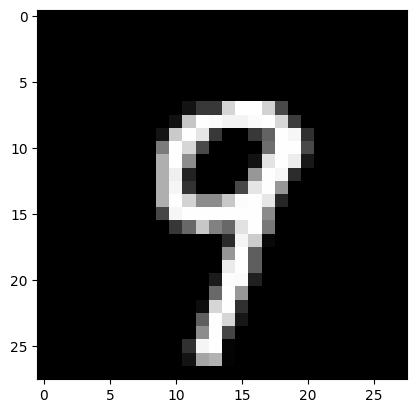

Prediction:  [8]
Label:  8


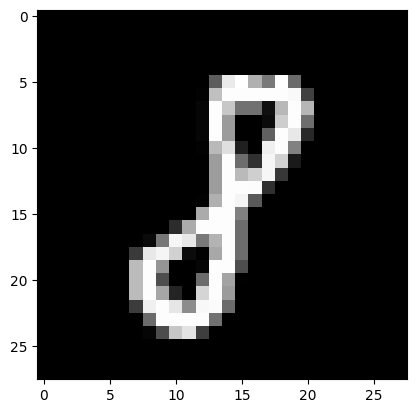

Prediction:  [9]
Label:  9


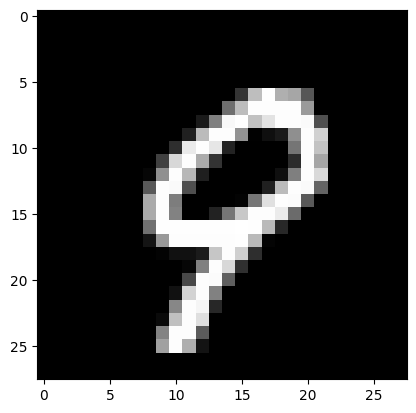

Prediction:  [0]
Label:  0


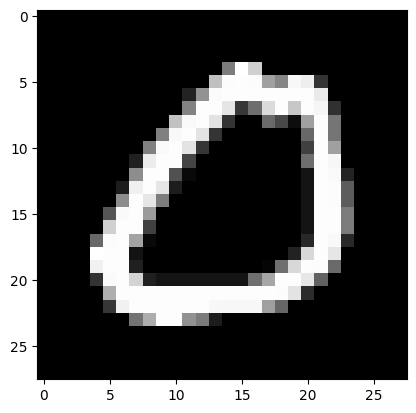

In [56]:
test_prediction(0, W1, b1, W2, b2)
test_prediction(1, W1, b1, W2, b2)
test_prediction(2, W1, b1, W2, b2)
test_prediction(3, W1, b1, W2, b2)

In [ ]:
dev_predictions = make_predictions(X_dev, W1, b1, W2, b2)
get_accuracy(dev_predictions, Y_dev)